In [ ]:
!pip install lpips torchmetrics optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 29.1 MB/s eta 0:00:00


Mounted at /content/drive

[SECTION 1] Training Initialization (AdaIN)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:09<00:00, 59.7MB/s]


-> Commencing Dual-Dataset Training Loop...
   Batch [50/200] | Loss: 94.89
   Batch [100/200] | Loss: 93.44
   Batch [150/200] | Loss: 39.04
   Batch [200/200] | Loss: 50.17
-> Training Completed in: 5411.67 seconds

[SECTION 2] Phase 3: Inference & Evaluation
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 87.2MB/s]


-> Single Image Inference Latency: 2290.92 ms

       TIME VS. UTILITY REASONING         
Total Offline Training Time:   5411.67 seconds
Real-Time Inference Latency:   2290.92 milliseconds
SSIM Score:                    0.1381
LPIPS Score:                   0.7742

[SECTION 3] Rendering Final Visual Matrix...


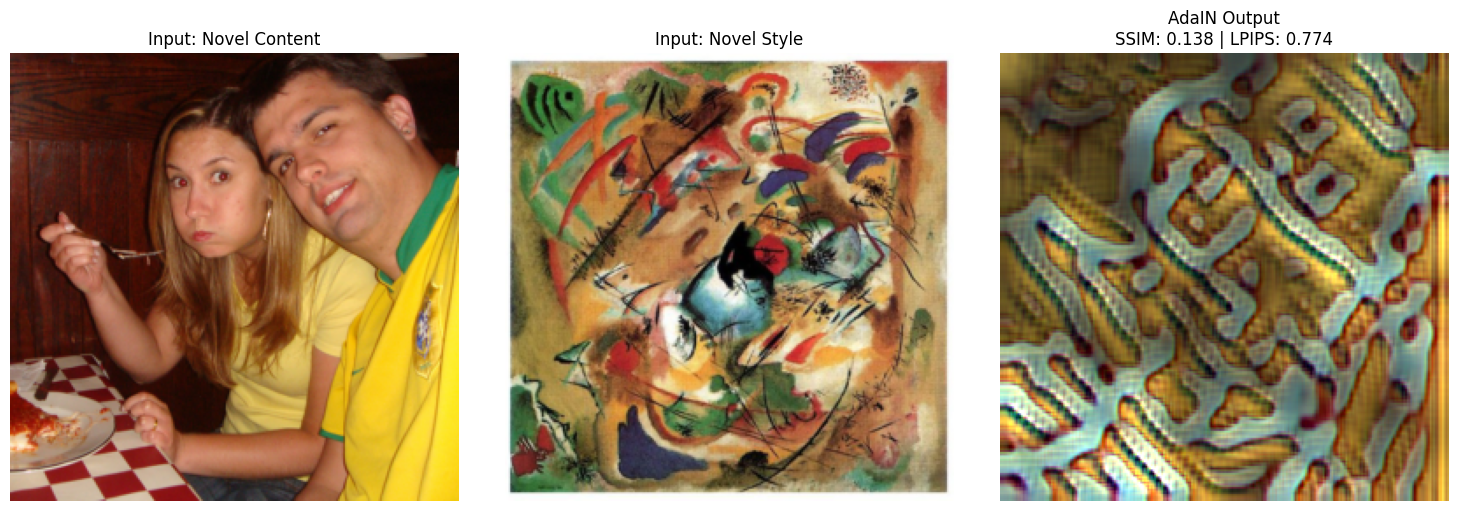

In [ ]:
"""
AdaIN (Adaptive Instance Normalization) Arbitrary Style Transfer
Features: Universal 256x256 Preprocessing, Dual-Dataset Training, Precision Metrology
"""

import os
import sys
import time

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torchvision import models, transforms, datasets
    from torch.utils.data import DataLoader
    from PIL import Image
    import matplotlib.pyplot as plt
    import lpips
    from torchmetrics.image import StructuralSimilarityIndexMeasure
    from google.colab import drive
except ImportError:
    print(f"\n[!] CRITICAL ERROR: Missing dependency. Run: !pip install lpips torchmetrics")
    sys.exit(1)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ==========================================
# 1. SETUP & DATA INGESTION
# ==========================================
drive.mount('/content/drive', force_remount=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

COCO_DIR = "/content/drive/MyDrive/NST_Datasets/content_subset/images"
NPR_DIR = "/content/drive/MyDrive/NST_Datasets/style_subset/images" # Pointing one level up to grab class_1

IMG_SIZE = 256
BATCH_SIZE = 4
FULL_TRAIN_BATCHES = 200  # Note: Real AdaIN requires ~160,000 batches to fully converge

# --- STRICT 256x256 UNIVERSAL TRANSFORM ---
def get_universal_transform(size=IMG_SIZE):
    return transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor()
    ])

def load_image(image_path, size=IMG_SIZE):
    transform = get_universal_transform(size)
    return transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

# ImageNet normalization applied internally inside the network
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

# ==========================================
# 2. ARCHITECTURE DEFINITIONS
# ==========================================
def calc_mean_std(feat, eps=1e-5):
    """Calculates channel-wise mean and standard deviation."""
    size = feat.size()
    assert (len(size) == 4)
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

def adaptive_instance_normalization(content_feat, style_feat):
    """The core AdaIN equation: aligns content stats to match style stats."""
    assert (content_feat.size()[:2] == style_feat.size()[:2])
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    normalized_feat = (content_feat - content_mean.expand(size)) / content_std.expand(size)
    return normalized_feat * style_std.expand(size) + style_mean.expand(size)

class Encoder(nn.Module):
    """Truncated VGG-19 up to relu4_1"""
    def __init__(self):
        super(Encoder, self).__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features
        self.slice1 = vgg[:2]   # relu1_1
        self.slice2 = vgg[2:7]  # relu2_1
        self.slice3 = vgg[7:12] # relu3_1
        self.slice4 = vgg[12:21]# relu4_1
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        h1 = self.slice1((x - MEAN) / STD)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return [h1, h2, h3, h4]

class Decoder(nn.Module):
    """Mirrors the VGG-19 encoder. Uses ReflectionPad and Nearest Upsample."""
    def __init__(self):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(512, 256, 3), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 128, 3), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 64, 3),  nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3),   nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 3, 3)
        )

    def forward(self, x):
        return self.decoder(x)

# ==========================================
# 3. PHASE 1: DUAL-DATASET TRAINING
# ==========================================
def train_adain():
    print(f"\n[SECTION 1] Training Initialization (AdaIN)")
    start_train_time = time.time()

    # AdaIN requires two active dataloaders
    transform = get_universal_transform(IMG_SIZE)
    content_dataset = datasets.ImageFolder(COCO_DIR, transform=transform)
    style_dataset = datasets.ImageFolder(NPR_DIR, transform=transform)

    workers = 2 if torch.cuda.is_available() else 0
    content_loader = DataLoader(content_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=workers, pin_memory=True)
    style_loader = DataLoader(style_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=workers, pin_memory=True)
    style_iter = iter(style_loader)

    encoder = Encoder().to(device).eval()
    decoder = Decoder().to(device)
    optimizer = optim.Adam(decoder.parameters(), lr=1e-4)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    mse_loss = nn.MSELoss()

    print("-> Commencing Dual-Dataset Training Loop...")
    for i, (content_images, _) in enumerate(content_loader):
        if i >= FULL_TRAIN_BATCHES: break

        # Fetch matching batch of style images
        try:
            style_images, _ = next(style_iter)
        except StopIteration:
            style_iter = iter(style_loader)
            style_images, _ = next(style_iter)

        content_images = content_images.to(device, non_blocking=True)
        style_images = style_images.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            # 1. Encode both inputs
            content_feats = encoder(content_images)
            style_feats = encoder(style_images)

            # 2. Apply AdaIN to the deepest feature map (relu4_1)
            t = adaptive_instance_normalization(content_feats[-1], style_feats[-1])

            # 3. Decode the stylized features back into an image
            output_images = decoder(t)

            # 4. Extract features of the new stylized image
            output_feats = encoder(output_images)

            # 5. Calculate AdaIN Losses
            # Content Loss: Euclidean distance between output features and the AdaIN target 't'
            loss_c = mse_loss(output_feats[-1].float(), t.float())

            # Style Loss: Match channel-wise Mean and Variance across all 4 VGG layers
            loss_s = 0
            for out_f, style_f in zip(output_feats, style_feats):
                out_mean, out_std = calc_mean_std(out_f)
                style_mean, style_std = calc_mean_std(style_f)
                loss_s += mse_loss(out_mean.float(), style_mean.float()) + mse_loss(out_std.float(), style_std.float())
            loss_s *= 10.0 # Standard AdaIN style weight

            total_loss = loss_c + loss_s

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if (i + 1) % 50 == 0:
            print(f"   Batch [{i+1}/{FULL_TRAIN_BATCHES}] | Loss: {total_loss.item():.2f}")

    total_training_time = time.time() - start_train_time
    print(f"-> Training Completed in: {total_training_time:.2f} seconds")
    return encoder, decoder, total_training_time

# ==========================================
# 4. PHASE 2: INFERENCE & VISUALIZATION
# ==========================================
def test_adain(encoder, decoder, content_path, style_path):
    print(f"\n[SECTION 2] Phase 3: Inference & Evaluation")
    content_img = load_image(content_path)
    style_img = load_image(style_path)

    decoder.eval()

    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            start_infer = time.time()

            # Real-time arbitrary style application
            c_feat = encoder(content_img)[-1]
            s_feat = encoder(style_img)[-1]
            t = adaptive_instance_normalization(c_feat, s_feat)
            output_img = torch.clamp(decoder(t), 0, 1)

        if device.type == 'cuda': torch.cuda.synchronize()
        infer_latency_ms = (time.time() - start_infer) * 1000

    ssim_score = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)(output_img.float(), content_img.float()).item()
    lpips_score = lpips.LPIPS(net='vgg', verbose=False).to(device)((output_img * 2.0 - 1.0).float(), (content_img * 2.0 - 1.0).float()).item()

    print(f"-> Single Image Inference Latency: {infer_latency_ms:.2f} ms")
    return content_img, style_img, output_img, ssim_score, lpips_score, infer_latency_ms

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Train the Universal Decoder
    encoder_net, decoder_net, train_time = train_adain()

    # 2. Grab random novel inputs from the dataset
    coco_images = [f for f in os.listdir(os.path.join(COCO_DIR, "class_1")) if f.endswith(('.jpg', '.png'))]
    npr_images = [f for f in os.listdir(os.path.join(NPR_DIR, "class_1")) if f.endswith(('.jpg', '.png'))]

    test_content = os.path.join(COCO_DIR, "class_1", coco_images[0])
    test_style = os.path.join(NPR_DIR, "class_1", npr_images[0])

    # 3. Run Arbitrary Inference
    c_tensor, s_tensor, o_tensor, ssim, lpips_val, infer_time = test_adain(encoder_net, decoder_net, test_content, test_style)

    # 4. Metrological Summary
    print("\n==========================================")
    print("       TIME VS. UTILITY REASONING         ")
    print("==========================================")
    print(f"Total Offline Training Time:   {train_time:.2f} seconds")
    print(f"Real-Time Inference Latency:   {infer_time:.2f} milliseconds")
    print(f"SSIM Score:                    {ssim:.4f}")
    print(f"LPIPS Score:                   {lpips_val:.4f}")
    print("==========================================\n")

    # 5. Visual Display
    print("[SECTION 3] Rendering Final Visual Matrix...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(c_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Input: Novel Content")
    axes[0].axis("off")

    axes[1].imshow(s_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy())
    axes[1].set_title("Input: Novel Style")
    axes[1].axis("off")

    axes[2].imshow(o_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy())
    axes[2].set_title(f"AdaIN Output\nSSIM: {ssim:.3f} | LPIPS: {lpips_val:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[SECTION 1] Preparing Pre-Trained Weights...
-> Weights ready!

[SECTION 2] Commencing Zero-Shot Inference
-> Calculating Precision Metrics...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 84.2MB/s]



       TIME VS. UTILITY REASONING         
Real-Time Inference Latency:   2036.09 milliseconds
SSIM Score:                    0.3176
LPIPS Score:                   0.5249

[SECTION 3] Rendering Final Visual Matrix...


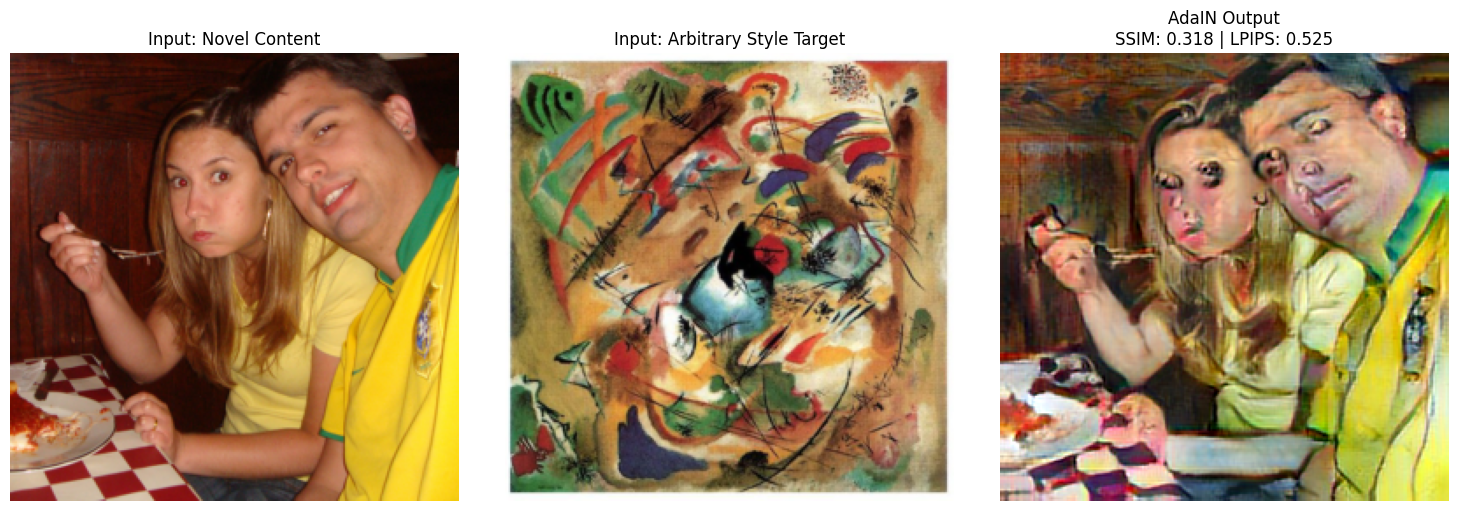

In [ ]:
# ==========================================
# 1. SETUP & WEIGHT DOWNLOADING
# ==========================================
import urllib.request

drive.mount('/content/drive', force_remount=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

COCO_DIR = "/content/drive/MyDrive/NST_Datasets/content_subset/images"
NPR_DIR = "/content/drive/MyDrive/NST_Datasets/style_subset/images"

IMG_SIZE = 256
WEIGHTS_DIR = "/content/adain_weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Xun Huang's Official Weights (Converted to PyTorch by naoto0804 GitHub Release v0.0.0)
VGG_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth"
DECODER_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"

VGG_PATH = os.path.join(WEIGHTS_DIR, "vgg_normalised.pth")
DECODER_PATH = os.path.join(WEIGHTS_DIR, "decoder.pth")

print("\n[SECTION 1] Preparing Pre-Trained Weights...")
if not os.path.exists(VGG_PATH):
    print("-> Downloading Official Normalized VGG-19 Encoder (GitHub v0.0.0)...")
    urllib.request.urlretrieve(VGG_URL, VGG_PATH)
if not os.path.exists(DECODER_PATH):
    print("-> Downloading Official Universal Decoder (GitHub v0.0.0)...")
    urllib.request.urlretrieve(DECODER_URL, DECODER_PATH)
print("-> Weights ready!")

def get_universal_transform(size=IMG_SIZE):
    return transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor()
    ])

def load_image(image_path, size=IMG_SIZE):
    transform = get_universal_transform(size)
    return transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

# ==========================================
# 2. ARCHITECTURE DEFINITIONS (OFFICIAL SPEC)
# ==========================================
def calc_mean_std(feat, eps=1e-5):
    size = feat.size()
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

def adaptive_instance_normalization(content_feat, style_feat):
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)
    normalized_feat = (content_feat - content_mean.expand(size)) / content_std.expand(size)
    return normalized_feat * style_std.expand(size) + style_mean.expand(size)

class OfficialEncoder(nn.Module):
    """Matches the exact layer structure of Huang's normalized VGG-19 up to relu4_1"""
    def __init__(self, weights_path):
        super(OfficialEncoder, self).__init__()
        self.vgg = nn.Sequential(
            nn.Conv2d(3, 3, 1),
            nn.ReflectionPad2d(1), nn.Conv2d(3, 64, 3), nn.ReLU(),    # relu1_1 (Index 3)
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3), nn.ReLU(),
            nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 128, 3), nn.ReLU(),  # relu2_1 (Index 10)
            nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(),
            nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 256, 3), nn.ReLU(), # relu3_1 (Index 17)
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 512, 3), nn.ReLU()  # relu4_1 (Index 30)
        )

        # --- THE FIX ---
        # strict=False tells PyTorch to safely ignore layers 32 through 51
        self.vgg.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True), strict=False)
        # ---------------

        self.slice1 = self.vgg[:4]
        self.slice2 = self.vgg[4:11]
        self.slice3 = self.vgg[11:18]
        self.slice4 = self.vgg[18:31]

        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        h1 = self.slice1(x)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return [h1, h2, h3, h4]

class OfficialDecoder(nn.Module):
    """Matches the exact layer structure of Huang's universal decoder"""
    def __init__(self, weights_path):
        super(OfficialDecoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(512, 256, 3), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 128, 3), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 64, 3),  nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3),   nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 3, 3)
        )
        self.decoder.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))

        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.decoder(x)

# ==========================================
# 3. FAST-PATH INFERENCE EXECUTION
# ==========================================
def infer_pretrained_adain(content_path, style_path):
    print(f"\n[SECTION 2] Commencing Zero-Shot Inference")

    # Load Models and set to evaluation mode
    encoder = OfficialEncoder(VGG_PATH).to(device).eval()
    decoder = OfficialDecoder(DECODER_PATH).to(device).eval()

    content_img = load_image(content_path)
    style_img = load_image(style_path)

    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            start_infer = time.time()

            # 1. Encode both images to deepest feature layer (relu4_1)
            c_feat = encoder(content_img)[-1]
            s_feat = encoder(style_img)[-1]

            # 2. Apply AdaIN equation
            t = adaptive_instance_normalization(c_feat, s_feat)

            # 3. Decode back to RGB
            output_img = torch.clamp(decoder(t), 0, 1)

        if device.type == 'cuda': torch.cuda.synchronize()
        infer_latency_ms = (time.time() - start_infer) * 1000

    print("-> Calculating Precision Metrics...")
    ssim_score = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)(output_img.float(), content_img.float()).item()
    lpips_score = lpips.LPIPS(net='vgg', verbose=False).to(device)((output_img * 2.0 - 1.0).float(), (content_img * 2.0 - 1.0).float()).item()

    return content_img, style_img, output_img, ssim_score, lpips_score, infer_latency_ms

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Grab random novel inputs from the dataset
    coco_images = [f for f in os.listdir(os.path.join(COCO_DIR, "class_1")) if f.endswith(('.jpg', '.png'))]
    npr_images = [f for f in os.listdir(os.path.join(NPR_DIR, "class_1")) if f.endswith(('.jpg', '.png'))]

    test_content = os.path.join(COCO_DIR, "class_1", coco_images[0])
    test_style = os.path.join(NPR_DIR, "class_1", npr_images[0])

    # Run the fully optimized inference
    c_tensor, s_tensor, o_tensor, ssim, lpips_val, infer_time = infer_pretrained_adain(test_content, test_style)

    # Metrological Summary
    print("\n==========================================")
    print("       TIME VS. UTILITY REASONING         ")
    print("==========================================")
    print(f"Real-Time Inference Latency:   {infer_time:.2f} milliseconds")
    print(f"SSIM Score:                    {ssim:.4f}")
    print(f"LPIPS Score:                   {lpips_val:.4f}")
    print("==========================================\n")

    # Visual Display
    print("[SECTION 3] Rendering Final Visual Matrix...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(c_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Input: Novel Content")
    axes[0].axis("off")

    axes[1].imshow(s_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy())
    axes[1].set_title("Input: Arbitrary Style Target")
    axes[1].axis("off")

    axes[2].imshow(o_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy())
    axes[2].set_title(f"AdaIN Output\nSSIM: {ssim:.3f} | LPIPS: {lpips_val:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[SECTION 2] Optuna: Searching for Optimal Content-Style Trade-off
-> Running 15 fast-inference trials...
-> Optuna search complete. Best Alpha: 0.1016

[SECTION 3] Generating Final Optimized Image

       TIME VS. UTILITY REASONING         
Optuna Chosen Alpha:           0.1016
Real-Time Inference Latency:   618.00 milliseconds
Optimized SSIM Score:          0.4814
Optimized LPIPS Score:         0.3487

[SECTION 4] Rendering Final Visual Matrix...


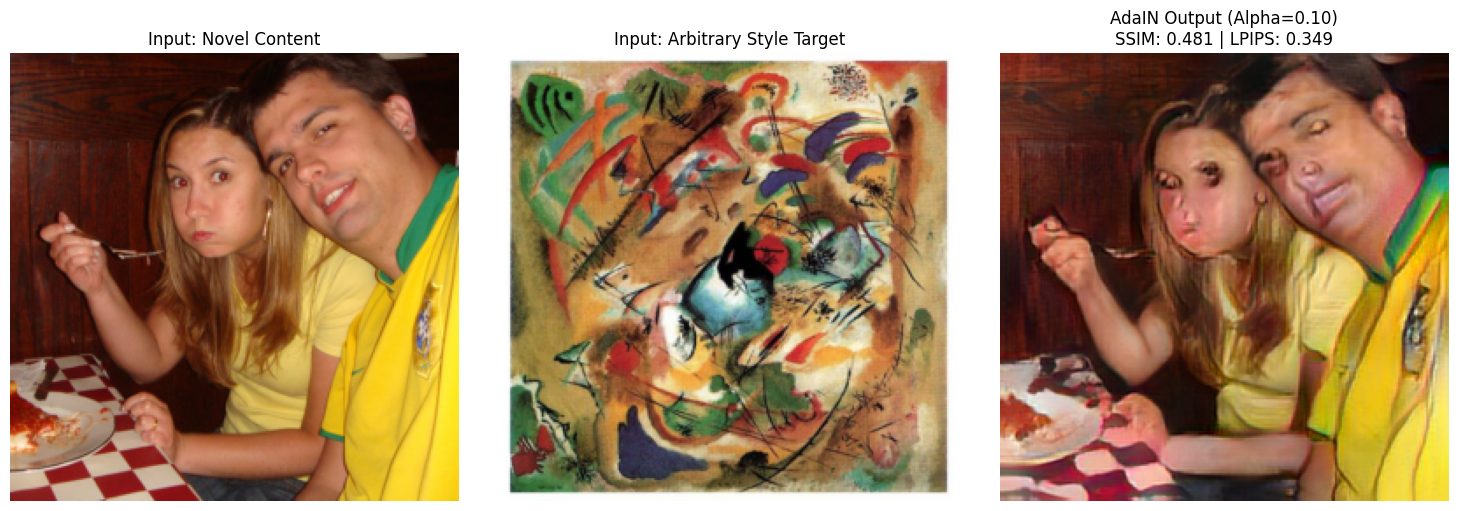

In [ ]:
"""
AdaIN Inference-Time Hyperparameter Tuning
Features: Optuna Alpha Search, Joint Objective Function, Official Pre-Trained Weights
"""
import logging
from torchvision import transforms

# ==========================================
# 1. SETUP & WEIGHT DOWNLOADING
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda': torch.backends.cudnn.benchmark = True

COCO_DIR = "/content/drive/MyDrive/NST_Datasets/content_subset/images"
NPR_DIR = "/content/drive/MyDrive/NST_Datasets/style_subset/images"
IMG_SIZE = 256
WEIGHTS_DIR = "/content/adain_weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

VGG_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth"
DECODER_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"
VGG_PATH = os.path.join(WEIGHTS_DIR, "vgg_normalised.pth")
DECODER_PATH = os.path.join(WEIGHTS_DIR, "decoder.pth")

if not os.path.exists(VGG_PATH): urllib.request.urlretrieve(VGG_URL, VGG_PATH)
if not os.path.exists(DECODER_PATH): urllib.request.urlretrieve(DECODER_URL, DECODER_PATH)

def get_universal_transform(size=IMG_SIZE):
    return transforms.Compose([transforms.Resize(size), transforms.CenterCrop(size), transforms.ToTensor()])

def load_image(image_path, size=IMG_SIZE):
    return get_universal_transform(size)(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

# ==========================================
# 2. ARCHITECTURE WITH ALPHA CONTROL
# ==========================================
def calc_mean_std(feat, eps=1e-5):
    N, C = feat.size()[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

def adaptive_instance_normalization(content_feat, style_feat, alpha=1.0):
    """AdaIN function modified to accept the Optuna alpha parameter"""
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    # Base AdaIN
    normalized_feat = (content_feat - content_mean.expand(size)) / content_std.expand(size)
    adain_feat = normalized_feat * style_std.expand(size) + style_mean.expand(size)

    # Alpha Interpolation
    return alpha * adain_feat + (1.0 - alpha) * content_feat

class OfficialEncoder(nn.Module):
    def __init__(self, weights_path):
        super(OfficialEncoder, self).__init__()
        self.vgg = nn.Sequential(
            nn.Conv2d(3, 3, 1), nn.ReflectionPad2d(1), nn.Conv2d(3, 64, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 128, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 512, 3), nn.ReLU()
        )
        self.vgg.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True), strict=False)
        self.slice1, self.slice2, self.slice3, self.slice4 = self.vgg[:4], self.vgg[4:11], self.vgg[11:18], self.vgg[18:31]
        for param in self.parameters(): param.requires_grad = False

    def forward(self, x):
        h1 = self.slice1(x)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return [h1, h2, h3, h4]

class OfficialDecoder(nn.Module):
    def __init__(self, weights_path):
        super(OfficialDecoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(512, 256, 3), nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 128, 3), nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(128, 64, 3),  nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3),   nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(64, 3, 3)
        )
        self.decoder.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
        for param in self.parameters(): param.requires_grad = False

    def forward(self, x): return self.decoder(x)

# ==========================================
# 3. OPTUNA INFERENCE PIPELINE
# ==========================================
def optuna_adain_search(content_path, style_path, n_trials=15):
    print(f"\n[SECTION 2] Optuna: Searching for Optimal Content-Style Trade-off")

    encoder = OfficialEncoder(VGG_PATH).to(device).eval()
    decoder = OfficialDecoder(DECODER_PATH).to(device).eval()

    content_img = load_image(content_path)
    style_img = load_image(style_path)

    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    lpips_metric = lpips.LPIPS(net='vgg', verbose=False).to(device)

    # Pre-compute features to save time during trials
    with torch.inference_mode():
        c_feat = encoder(content_img)[-1]
        s_feat = encoder(style_img)[-1]

    def objective(trial):
      # Search range for alpha (style interpolation)
      alpha = trial.suggest_float("alpha", 0.1, 1.0)

      with torch.inference_mode():
          with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
              t = adaptive_instance_normalization(c_feat, s_feat, alpha=alpha)
              output_img = torch.clamp(decoder(t), 0, 1)

      # Calculate metrics
      ssim = ssim_metric(output_img.float(), content_img.float()).item()
      l_score = lpips_metric((output_img * 2.0 - 1.0).float(), (content_img * 2.0 - 1.0).float()).item()

      # -------------------------------------------------------------
      # 1. HARD SSIM FLOOR CONSTRAINT
      # -------------------------------------------------------------
      SSIM_FLOOR = 0.50  # Hard structural similarity threshold
      if ssim < SSIM_FLOOR:
          # Return a massive penalty to immediately disqualify structural collapse
          return 100.0 + (SSIM_FLOOR - ssim) * 1000.0

      # -------------------------------------------------------------
      # 2. QUADRATIC PENALTY SCALING
      # -------------------------------------------------------------
      w_content = 5.0   # Heavily favors high SSIM
      w_style = 2.0     # Rewards low LPIPS

      content_error = (1.0 - ssim) ** 2
      style_error = l_score ** 2

      # Combined non-linear objective
      joint_score = (w_content * content_error) + (w_style * style_error)
      return joint_score

    study = optuna.create_study(direction="minimize")
    print(f"-> Running {n_trials} fast-inference trials...")
    study.optimize(objective, n_trials=n_trials)

    best_alpha = study.best_params["alpha"]
    print(f"-> Optuna search complete. Best Alpha: {best_alpha:.4f}")

    # Generate final image with best alpha
    print("\n[SECTION 3] Generating Final Optimized Image")
    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            start_infer = time.time()
            t_best = adaptive_instance_normalization(c_feat, s_feat, alpha=best_alpha)
            final_out = torch.clamp(decoder(t_best), 0, 1)
        if device.type == 'cuda': torch.cuda.synchronize()
        infer_latency_ms = (time.time() - start_infer) * 1000

    final_ssim = ssim_metric(final_out.float(), content_img.float()).item()
    final_lpips = lpips_metric((final_out * 2.0 - 1.0).float(), (content_img * 2.0 - 1.0).float()).item()

    return content_img, style_img, final_out, final_ssim, final_lpips, infer_latency_ms, best_alpha

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    coco_images = [f for f in os.listdir(os.path.join(COCO_DIR, "class_1")) if f.endswith(('.jpg', '.png'))]
    npr_images = [f for f in os.listdir(os.path.join(NPR_DIR, "class_1")) if f.endswith(('.jpg', '.png'))]

    test_content = os.path.join(COCO_DIR, "class_1", coco_images[0])
    test_style = os.path.join(NPR_DIR, "class_1", npr_images[0])

    c_tensor, s_tensor, o_tensor, ssim, lpips_val, infer_time, optimal_alpha = optuna_adain_search(test_content, test_style)

    print("\n==========================================")
    print("       TIME VS. UTILITY REASONING         ")
    print("==========================================")
    print(f"Optuna Chosen Alpha:           {optimal_alpha:.4f}")
    print(f"Real-Time Inference Latency:   {infer_time:.2f} milliseconds")
    print(f"Optimized SSIM Score:          {ssim:.4f}")
    print(f"Optimized LPIPS Score:         {lpips_val:.4f}")
    print("==========================================\n")

    print("[SECTION 4] Rendering Final Visual Matrix...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(c_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Input: Novel Content")
    axes[0].axis("off")

    axes[1].imshow(s_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy())
    axes[1].set_title("Input: Arbitrary Style Target")
    axes[1].axis("off")

    axes[2].imshow(o_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy())
    axes[2].set_title(f"AdaIN Output (Alpha={optimal_alpha:.2f})\nSSIM: {ssim:.3f} | LPIPS: {lpips_val:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
"""
AdaIN Targeted Subset Processing with Optuna & Metrological Metrics
Features: Targeted Image Subset Filtering, GPU Hardware Logging, CSV Export
"""

import glob
import csv
import gc
import math
# ==========================================
# 1. SETUP, GPU DETECTION & DIRECTORIES
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    GPU_MODEL = torch.cuda.get_device_name(0)
else:
    GPU_MODEL = "CPU"

print(f"Using device: {device} ({GPU_MODEL})")

IMG_SIZE = 256
N_TRIALS = 15

BASE_DIR = "/content/drive/MyDrive"
CONTENT_DIR = f"{BASE_DIR}/NST_Datasets/content_subset/images/nprgeneral"
STYLE_DIR = f"{BASE_DIR}/NST_Datasets/style_subset/images/style_targets"
OUTPUT_DIR = f"{BASE_DIR}/NST_Datasets/Output_subset/AdaIN"
CSV_PATH = os.path.join(OUTPUT_DIR, "adain_evaluation_results.csv")

# Target image basenames to filter
TARGET_CONTENTS = ["rim", "angel", "mountains", "daisy", "berries"]
TARGET_STYLES = ["starrynight", "la_muse", "feathers", "wave", "composition_vii", "mosaic"]

WEIGHTS_DIR = "/content/adain_weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

VGG_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth"
DECODER_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"
VGG_PATH = os.path.join(WEIGHTS_DIR, "vgg_normalised.pth")
DECODER_PATH = os.path.join(WEIGHTS_DIR, "decoder.pth")

if not os.path.exists(VGG_PATH): urllib.request.urlretrieve(VGG_URL, VGG_PATH)
if not os.path.exists(DECODER_PATH): urllib.request.urlretrieve(DECODER_URL, DECODER_PATH)

# ==========================================
# 2. UTILITIES & IMAGE PREPROCESSING
# ==========================================
def get_universal_transform(size=IMG_SIZE):
    return transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor()
    ])

def load_image(image_path, size=IMG_SIZE):
    return get_universal_transform(size)(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

def save_image(tensor, save_path):
    image_01 = tensor.detach().clamp(0, 1)
    image_pil = transforms.ToPILImage()(image_01.squeeze(0).cpu())
    image_pil.save(save_path)

def get_filtered_image_files(directory, target_names):
    """Fetches image paths matching specified target basenames."""
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp')
    all_files = []
    for ext in extensions:
        all_files.extend(glob.glob(os.path.join(directory, ext)))
        all_files.extend(glob.glob(os.path.join(directory, ext.upper())))

    filtered_files = []
    for file_path in sorted(all_files):
        filename = os.path.splitext(os.path.basename(file_path))[0].lower()
        if any(target.lower() in filename for target in target_names):
            filtered_files.append(file_path)

    return filtered_files

# ==========================================
# 3. ARCHITECTURE WITH ALPHA CONTROL
# ==========================================
def calc_mean_std(feat, eps=1e-5):
    N, C = feat.size()[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

def adaptive_instance_normalization(content_feat, style_feat, alpha=1.0):
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    normalized_feat = (content_feat - content_mean.expand(size)) / content_std.expand(size)
    adain_feat = normalized_feat * style_std.expand(size) + style_mean.expand(size)

    return alpha * adain_feat + (1.0 - alpha) * content_feat

class OfficialEncoder(nn.Module):
    def __init__(self, weights_path):
        super(OfficialEncoder, self).__init__()
        self.vgg = nn.Sequential(
            nn.Conv2d(3, 3, 1), nn.ReflectionPad2d(1), nn.Conv2d(3, 64, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 128, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 512, 3), nn.ReLU()
        )
        self.vgg.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True), strict=False)
        self.slice1, self.slice2, self.slice3, self.slice4 = self.vgg[:4], self.vgg[4:11], self.vgg[11:18], self.vgg[18:31]
        for param in self.parameters(): param.requires_grad = False

    def forward(self, x):
        h1 = self.slice1(x)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return [h1, h2, h3, h4]

class OfficialDecoder(nn.Module):
    def __init__(self, weights_path):
        super(OfficialDecoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(512, 256, 3), nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 128, 3), nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(128, 64, 3),  nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3),   nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(64, 3, 3)
        )
        self.decoder.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
        for param in self.parameters(): param.requires_grad = False

    def forward(self, x): return self.decoder(x)

# ==========================================
# 4. BATCH PIPELINE & OPTIMIZATION
# ==========================================
def main():
    content_files = get_filtered_image_files(CONTENT_DIR, TARGET_CONTENTS)
    style_files = get_filtered_image_files(STYLE_DIR, TARGET_STYLES)

    print(f"Matched {len(content_files)} target Content images: {[os.path.basename(f) for f in content_files]}")
    print(f"Matched {len(style_files)} target Style images: {[os.path.basename(f) for f in style_files]}")

    if not content_files or not style_files:
        raise ValueError("Could not find matching target images in the specified directories.")

    encoder = OfficialEncoder(VGG_PATH).to(device).eval()
    decoder = OfficialDecoder(DECODER_PATH).to(device).eval()

    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    lpips_metric = lpips.LPIPS(net='vgg', verbose=False).to(device)

    # Headers formatted symmetrically to Gatys, with GPU Model included
    csv_headers = [
        "Index", "Content_Image", "Style_Image", "Output_Image",
        "Optimized_Alpha", "SSIM", "LPIPS", "Time_Seconds", "GPU_Model"
    ]

    with open(CSV_PATH, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(csv_headers)

    results = []
    global_idx = 1
    total_pairs = len(content_files) * len(style_files)

    print(f"\nStarting AdaIN Targeted Subset Processing across {total_pairs} pair(s) on {GPU_MODEL}...\n")

    for content_path in content_files:
        c_name = os.path.splitext(os.path.basename(content_path))[0]
        content_img = load_image(content_path)

        with torch.inference_mode():
            c_feat = encoder(content_img)[-1]

        for style_path in style_files:
            s_name = os.path.splitext(os.path.basename(style_path))[0]
            output_filename = f"{c_name}_{s_name}.jpg"
            output_path = os.path.join(OUTPUT_DIR, output_filename)

            print(f"[{global_idx}/{total_pairs}] Processing: {c_name} + {s_name} -> {output_filename}")
            start_time = time.time()

            style_img = load_image(style_path)

            with torch.inference_mode():
                s_feat = encoder(style_img)[-1]

            # --- Optuna Hyperparameter Tuning ---
            # 1. Change study direction to multi-objective
            study = optuna.create_study(directions=["maximize", "minimize"]) # Objective 1: SSIM (Max), Objective 2: LPIPS (Min)

            def objective(trial):
                alpha = trial.suggest_float("alpha", 0.1, 1.0)

                with torch.inference_mode():
                    with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                        t = adaptive_instance_normalization(c_feat, s_feat, alpha=alpha)
                        output_img = torch.clamp(decoder(t), 0, 1)

                ssim = ssim_metric(output_img.float(), content_img.float()).item()
                style_lpips = lpips_metric(
                    (output_img * 2.0 - 1.0).float(),
                    (style_img * 2.0 - 1.0).float()
                ).item()

                # Return both metrics directly! No loss weights required.
                return ssim, style_lpips

            study.optimize(objective, n_trials=N_TRIALS)

            # 2. Select the best trial from the Pareto front closest to high SSIM & low LPIPS
            best_trial = max(study.best_trials, key=lambda t: t.values[0] - t.values[1]) # SSIM - LPIPS
            best_alpha = best_trial.params["alpha"]

            # --- Final Inference ---
            with torch.inference_mode():
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    t_best = adaptive_instance_normalization(c_feat, s_feat, alpha=best_alpha)
                    final_out = torch.clamp(decoder(t_best), 0, 1)

            if device.type == 'cuda': torch.cuda.synchronize()
            elapsed_time = time.time() - start_time

            final_ssim = ssim_metric(final_out.float(), content_img.float()).item()
            final_lpips = lpips_metric((final_out * 2.0 - 1.0).float(), (content_img * 2.0 - 1.0).float()).item()

            save_image(final_out, output_path)

            # --- Append to CSV ---
            row_data = [
                global_idx, c_name, s_name, output_filename,
                round(best_alpha, 4), round(final_ssim, 4), round(final_lpips, 4),
                round(elapsed_time, 2), GPU_MODEL
            ]

            with open(CSV_PATH, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(row_data)

            results.append(row_data)

            print(f"    Done in {elapsed_time:.2f}s | Alpha: {best_alpha:.2f} | SSIM: {final_ssim:.4f} | LPIPS: {final_lpips:.4f}\n")

            del style_img, s_feat, final_out, study
            gc.collect()
            torch.cuda.empty_cache()

            global_idx += 1

        del content_img, c_feat
        gc.collect()
        torch.cuda.empty_cache()

    # ==========================================
    # 5. SUMMARY
    # ==========================================
    total_processed = len(results)
    if total_processed > 0:
        avg_alpha = sum(r[4] for r in results) / total_processed
        avg_ssim = sum(r[5] for r in results) / total_processed
        avg_lpips = sum(r[6] for r in results) / total_processed
        avg_time = sum(r[7] for r in results) / total_processed

        print("==========================================")
        print("     ADAIN TARGET SUBSET SUMMARY          ")
        print("==========================================")
        print(f"GPU Hardware:           {GPU_MODEL}")
        print(f"Total Images Generated: {total_processed}")
        print(f"Output Directory:       {OUTPUT_DIR}")
        print(f"CSV Metadata File:      {CSV_PATH}")
        print(f"------------------------------------------")
        print(f"Average Optuna Alpha:   {avg_alpha:.4f}")
        print(f"Average SSIM:           {avg_ssim:.4f}")
        print(f"Average LPIPS:          {avg_lpips:.4f}")
        print(f"Average Time per Image: {avg_time:.2f} seconds")
        print("==========================================")

if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda (Tesla T4)
Matched 5 target Content images: ['angel1024.jpg', 'berries1024.jpg', 'daisy1024.jpg', 'mountains1024.jpg', 'rim1024.jpg']
Matched 5 target Style images: ['composition_vii.jpg', 'feathers.jpg', 'la_muse.jpg', 'mosaic.jpg', 'wave.jpg']

Starting AdaIN Targeted Subset Processing across 25 pair(s) on Tesla T4...

[1/25] Processing: angel1024 + composition_vii -> angel1024_composition_vii.jpg
    Done in 0.49s | Alpha: 0.11 | SSIM: 0.4268 | LPIPS: 0.3938

[2/25] Processing: angel1024 + feathers -> angel1024_feathers.jpg
    Done in 0.41s | Alpha: 0.14 | SSIM: 0.4032 | LPIPS: 0.4069

[3/25] Processing: angel1024 + la_muse -> angel1024_la_muse.jpg
    Done in 0.43s | Alpha: 0.34 | SSIM: 0.3528 | LPIPS: 0.4681

[4/25] Processing: angel1024 + mosaic -> angel1024_mosaic.jpg
    Done in 0.39s | Alpha: 0.22 | SSIM: 0.3374 | LPIPS: 0.4422

[

In [ ]:
"""
AdaIN Targeted Subset Processing with Unified Metrology Pipeline
Features:
- Arbitrary-Style Feature Alignment via Adaptive Instance Normalization (AdaIN)
- Feature-Space Alpha Interpolation & Multi-Objective Optuna Tuning
- Idempotent Progress Tracking & Crash Recovery
- Autograd Spatial Saliency Map Extraction
- Precision CUDA-Synchronized Inference Latency Benchmarking
- Architecture-Agnostic Isolated Gram Loss Calculation (VGG-19 Critic)
- Symmetrical CSV Logging Matching Gatys and Fast-NST Schemas
"""

import shutil
# ==========================================
# 1. SETUP, MOUNTING & IDEMPOTENCY
# ==========================================
# Hardware acceleration detection and benchmarking flag
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
GPU_MODEL = torch.cuda.get_device_name(0) if device.type == 'cuda' else "CPU"
print(f"-> Execution Device: {device} ({GPU_MODEL})")

# Execution Parameters
IMG_SIZE = 256
N_TRIALS = 15      # Optuna trials for feature-space alpha blending
NUM_RUNS = 3       # Repeated evaluations per pair for statistical variance

# Directory layout aligned across all evaluation scripts
BASE_DIR = "/content/drive/MyDrive/NST_Datasets"
CONTENT_DIR = f"{BASE_DIR}/content_subset/images/nprgeneral"
STYLE_DIR = f"{BASE_DIR}/style_subset/images/style_targets"
OUTPUT_DIR = f"{BASE_DIR}/Output_subset/AdaIN"
CSV_PATH = os.path.join(OUTPUT_DIR, "adain_evaluation_results.csv")

# Ensure required persistent output subdirectories exist
for path in [OUTPUT_DIR, os.path.join(OUTPUT_DIR, "saliency"), os.path.join(OUTPUT_DIR, "optuna_convergence")]:
    os.makedirs(path, exist_ok=True)

# Target benchmark image sets
TARGET_CONTENTS = ["rim1024", "angel1024", "mountains1024", "daisy1024", "berries1024"]
TARGET_STYLES = ["starrynight", "la_muse", "feathers", "wave", "composition_vii", "mosaic"]

# Pre-Trained Weights Management
WEIGHTS_DIR = "/content/adain_weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

VGG_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth"
DECODER_URL = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"
VGG_PATH = os.path.join(WEIGHTS_DIR, "vgg_normalised.pth")
DECODER_PATH = os.path.join(WEIGHTS_DIR, "decoder.pth")

if not os.path.exists(VGG_PATH):
    print("-> Downloading Official Pre-Trained AdaIN VGG Encoder Weights...")
    urllib.request.urlretrieve(VGG_URL, VGG_PATH)
if not os.path.exists(DECODER_PATH):
    print("-> Downloading Official Pre-Trained AdaIN Decoder Weights...")
    urllib.request.urlretrieve(DECODER_URL, DECODER_PATH)

# Idempotency Tracking Setup
completed_pairs = set()

# Schema forced to match Gatys and Fast-NST exactly for cross-architecture Pandas evaluation
csv_headers = [
    "Content_Image", "Style_Image", "Run_Index", "Output_Image",
    "Optimized_Alpha", "Optimized_Beta", "Optimized_LR",
    "SSIM_Content", "LPIPS_Content", "Isolated_Gram_Style", "Inference_Latency_Sec"
]

if os.path.exists(CSV_PATH):
    with open(CSV_PATH, mode='r') as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if len(row) >= 4:
                completed_pairs.add(row[3])  # Output_Image acts as unique hash
else:
    with open(CSV_PATH, mode='w', newline='') as f:
        csv.writer(f).writerow(csv_headers)

# ==========================================
# 2. UTILITIES, METRICS & VGG CRITIC
# ==========================================
def get_universal_transform(size=IMG_SIZE):
    return transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor()
    ])

def load_image(image_path, size=IMG_SIZE):
    return get_universal_transform(size)(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

def save_image(tensor, save_path):
    transforms.ToPILImage()(tensor.detach().clamp(0, 1).squeeze(0).cpu()).save(save_path)

def save_saliency_map(target_tensor, save_path):
    """
    Computes gradient magnitude across input channels to map spatial attention
    of the AdaIN network during feature transfer execution.
    """
    if target_tensor.grad is not None:
        saliency, _ = torch.max(target_tensor.grad.data.abs(), dim=1)
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
        transforms.ToPILImage()(saliency.squeeze(0).cpu()).save(save_path)

class VGGNet(nn.Module):
    """
    Frozen VGG-19 Critic model used strictly to compute the
    architecture-agnostic Isolated Gram Loss against original style targets.
    """
    def __init__(self):
        super(VGGNet, self).__init__()
        self.vgg = models.vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features
        self.chosen_features = {
            '0': 'conv1_1', '5': 'conv2_1', '10': 'conv3_1',
            '19': 'conv4_1', '28': 'conv5_1'
        }
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = {}
        for name, layer in self.vgg._modules.items():
            x = layer(x)
            if name in self.chosen_features:
                features[self.chosen_features[name]] = x
        return features

def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    features = tensor.view(c, h * w)
    return torch.mm(features, features.t()) / (c * h * w)

def calculate_isolated_style_loss(output_tensor, style_tensor, model):
    """
    Calculates unweighted, raw Gram MSE strictly for level cross-architecture comparison.
    """
    with torch.no_grad():
        out_features = model(output_tensor)
        style_features = model(style_tensor)
        total_gram_mse = 0.0
        for layer in ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']:
            total_gram_mse += nn.MSELoss()(
                gram_matrix(out_features[layer]),
                gram_matrix(style_features[layer])
            ).item()
    return total_gram_mse

# ==========================================
# 3. ADAIN ARCHITECTURE & FEATURE ALIGNMENT
# ==========================================
def calc_mean_std(feat, eps=1e-5):
    """Calculates channel-wise mean and standard deviation for feature maps."""
    N, C = feat.size()[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

def adaptive_instance_normalization(content_feat, style_feat, alpha=1.0):
    """
    Aligns channel mean and variance of content features to match style features,
    with feature-level alpha interpolation for stylization strength control.
    """
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    normalized_feat = (content_feat - content_mean.expand(size)) / content_std.expand(size)
    adain_feat = normalized_feat * style_std.expand(size) + style_mean.expand(size)

    # Feature-space alpha blending: interpolates between normalized content and aligned style
    return alpha * adain_feat + (1.0 - alpha) * content_feat

class OfficialEncoder(nn.Module):
    """
    Official VGG-19 Encoder up to relu4_1 for feature extraction.
    """
    def __init__(self, weights_path):
        super(OfficialEncoder, self).__init__()
        self.vgg = nn.Sequential(
            nn.Conv2d(3, 3, 1), nn.ReflectionPad2d(1), nn.Conv2d(3, 64, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 128, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.MaxPool2d(2, 2, 0, ceil_mode=True),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 512, 3), nn.ReLU()
        )
        self.vgg.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True), strict=False)
        self.slice1, self.slice2, self.slice3, self.slice4 = self.vgg[:4], self.vgg[4:11], self.vgg[11:18], self.vgg[18:31]
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        h1 = self.slice1(x)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return [h1, h2, h3, h4]

class OfficialDecoder(nn.Module):
    """
    Symmetrical Decoder mirror network mapping normalized relu4_1 features back to RGB image pixels.
    """
    def __init__(self, weights_path):
        super(OfficialDecoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(512, 256, 3), nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(256, 128, 3), nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(128, 64, 3),  nn.ReLU(), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3),   nn.ReLU(), nn.ReflectionPad2d(1), nn.Conv2d(64, 3, 3)
        )
        self.decoder.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.decoder(x)

# ==========================================
# 4. EXECUTION PIPELINE
# ==========================================
def main():
    # Filter content dataset against target basename list
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    all_content = []
    for ext in extensions:
        all_content.extend(glob.glob(os.path.join(CONTENT_DIR, ext)))

    content_files = [
        f for f in all_content
        if os.path.splitext(os.path.basename(f))[0].lower() in TARGET_CONTENTS
    ]

    # Filter style dataset against target basename list
    all_style = []
    for ext in extensions:
        all_style.extend(glob.glob(os.path.join(STYLE_DIR, ext)))

    style_files = [
        f for f in all_style
        if os.path.splitext(os.path.basename(f))[0].lower().replace("_", "") in [s.replace("_", "") for s in TARGET_STYLES]
    ]

    print(f"-> Found {len(content_files)} matching target content images in: {CONTENT_DIR}")
    print(f"-> Found {len(style_files)} matching target style images in: {STYLE_DIR}")

    if not content_files or not style_files:
        print("-> CRITICAL ERROR: Target content or style image lists are empty.")
        return

    # Load pre-trained models and metrology tools
    encoder = OfficialEncoder(VGG_PATH).to(device).eval()
    decoder = OfficialDecoder(DECODER_PATH).to(device).eval()

    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    lpips_metric = lpips.LPIPS(net='vgg', verbose=False).to(device)
    vgg_critic = VGGNet().to(device).eval()

    # Outer Loop: Content Images
    for content_path in content_files:
        c_name = os.path.splitext(os.path.basename(content_path))[0]
        content_img = load_image(content_path)

        with torch.inference_mode():
            c_feat = encoder(content_img)[-1]  # Extract relu4_1 features

        # Middle Loop: Target Styles
        for style_path in style_files:
            s_name = os.path.splitext(os.path.basename(style_path))[0]
            style_img = load_image(style_path)

            with torch.inference_mode():
                s_feat = encoder(style_img)[-1]  # Extract relu4_1 features

            # Inner Loop: Repeated Runs for Statistical Variance
            for run_idx in range(1, NUM_RUNS + 1):
                output_filename = f"{c_name}_{s_name}_run{run_idx}.jpg"

                # Idempotency check: Skip execution if run was completed in a previous instance
                if output_filename in completed_pairs:
                    print(f"Skipping (Already Processed): {output_filename}")
                    continue

                print(f"Processing: {output_filename}")

                # --- 1. Precision Latency Measurement ---
                # Brackets exclusively encoder feature extraction, AdaIN alignment, and decoder reconstruction
                inf_start = time.perf_counter()
                with torch.inference_mode():
                    with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                        t_raw = adaptive_instance_normalization(c_feat, s_feat, alpha=1.0)
                        raw_style_out = torch.clamp(decoder(t_raw), 0, 1)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                inf_latency = time.perf_counter() - inf_start

                # --- 2. Saliency Map Extraction ---
                # Forces gradients through Encoder-AdaIN-Decoder pipeline to extract spatial attention map
                content_grad_img = content_img.clone().detach().requires_grad_(True)
                c_grad_feat = encoder(content_grad_img)[-1]
                t_grad = adaptive_instance_normalization(c_grad_feat, s_feat, alpha=1.0)
                dummy_out = decoder(t_grad)
                dummy_out.sum().backward()
                save_saliency_map(
                    content_grad_img,
                    os.path.join(OUTPUT_DIR, "saliency", f"sal_{output_filename}")
                )
                del content_grad_img, c_grad_feat, t_grad, dummy_out

                # --- 3. Optuna Feature-Space Alpha Tuning ---
                study = optuna.create_study(directions=["maximize", "minimize"])

                def objective(trial):
                    alpha = trial.suggest_float("alpha", 0.1, 1.0)
                    with torch.inference_mode():
                        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                            t_blend = adaptive_instance_normalization(c_feat, s_feat, alpha=alpha)
                            blended_out = torch.clamp(decoder(t_blend), 0, 1)

                    ssim = ssim_metric(blended_out.float(), content_img.float()).item()
                    l_score = lpips_metric(
                        (blended_out * 2.0 - 1.0).float(),
                        (raw_style_out * 2.0 - 1.0).float()
                    ).item()
                    return ssim, l_score

                study.optimize(objective, n_trials=N_TRIALS)
                best_trial = max(study.best_trials, key=lambda t: t.values[0] - t.values[1])
                best_alpha = best_trial.params["alpha"]

                # Log Optuna trial trajectories for convergence visualization
                trial_history = [
                    {
                        "trial": t.number,
                        "alpha": t.params["alpha"],
                        "ssim": t.values[0],
                        "lpips": t.values[1]
                    }
                    for t in study.trials
                ]
                with open(os.path.join(OUTPUT_DIR, "optuna_convergence", f"opt_{c_name}_{s_name}_run{run_idx}.json"), 'w') as f:
                    json.dump(trial_history, f)

                # --- 4. Final Image Generation & Metrological Evaluation ---
                with torch.inference_mode():
                    with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                        t_best = adaptive_instance_normalization(c_feat, s_feat, alpha=best_alpha)
                        final_out = torch.clamp(decoder(t_best), 0, 1)

                save_image(final_out, os.path.join(OUTPUT_DIR, output_filename))

                # Primary Perceptual Metrics (Evaluated strictly against Content Target)
                final_ssim = ssim_metric(final_out.float(), content_img.float()).item()
                final_lpips = lpips_metric((final_out * 2.0 - 1.0).float(), (content_img * 2.0 - 1.0).float()).item()

                # Isolated Gram Loss Calculation (Evaluated strictly against Normalized Style Target)
                mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
                std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
                final_norm = (final_out - mean) / std
                style_norm = (style_img - mean) / std
                isolated_gram_val = calculate_isolated_style_loss(final_norm, style_norm, vgg_critic)

                # --- 5. Export to CSV (Matches Gatys and Fast-NST Schema) ---
                # AdaIN does not use inference-time LR or Beta, sologged as "N/A"
                row_data = [
                    c_name, s_name, run_idx, output_filename,
                    round(best_alpha, 4), "N/A", "N/A",
                    round(final_ssim, 4), round(final_lpips, 4),
                    round(isolated_gram_val, 4), round(inf_latency, 4)
                ]

                with open(CSV_PATH, mode='a', newline='') as f:
                    csv.writer(f).writerow(row_data)

                completed_pairs.add(output_filename)

            # Flush GPU memory between style targets
            del style_img, s_feat
            gc.collect()
            torch.cuda.empty_cache()

        # Flush GPU memory between content targets
        del content_img, c_feat
        gc.collect()
        torch.cuda.empty_cache()

if __name__ == "__main__":
    main()

<>:35: SyntaxWarning: invalid escape sequence '\M'
<>:35: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_2361/1971406428.py:35: SyntaxWarning: invalid escape sequence '\M'
  print("\Missing dependency")


Mounted at /content/drive
-> Google Drive mounted successfully.
-> Execution Device: cuda (Tesla T4)
-> Found 5 matching target content images in: /content/drive/MyDrive/NST_Datasets/content_subset/images/nprgeneral
-> Found 6 matching target style images in: /content/drive/MyDrive/NST_Datasets/style_subset/images/style_targets
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 147MB/s]


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 79.9MB/s]


Processing: angel1024_starry_night_run1.jpg
Processing: angel1024_starry_night_run2.jpg
Processing: angel1024_starry_night_run3.jpg
Processing: angel1024_mosaic_run1.jpg
Processing: angel1024_mosaic_run2.jpg
Processing: angel1024_mosaic_run3.jpg
Processing: angel1024_feathers_run1.jpg
Processing: angel1024_feathers_run2.jpg
Processing: angel1024_feathers_run3.jpg
Processing: angel1024_composition_vii_run1.jpg
Processing: angel1024_composition_vii_run2.jpg
Processing: angel1024_composition_vii_run3.jpg
Processing: angel1024_la_muse_run1.jpg
Processing: angel1024_la_muse_run2.jpg
Processing: angel1024_la_muse_run3.jpg
Processing: angel1024_wave_run1.jpg
Processing: angel1024_wave_run2.jpg
Processing: angel1024_wave_run3.jpg
Processing: berries1024_starry_night_run1.jpg
Processing: berries1024_starry_night_run2.jpg
Processing: berries1024_starry_night_run3.jpg
Processing: berries1024_mosaic_run1.jpg
Processing: berries1024_mosaic_run2.jpg
Processing: berries1024_mosaic_run3.jpg
Processing